In [1]:
import gsd.hoomd
import freud
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import signac
project=signac.get_project()

In [2]:
def harmonic_U(k, sigma, r):
    V = k/2 * pow((1. - r/sigma), 2)
    return V
        
def harmonic_F(k, sigma, r):
    F = k/sigma * (1. - r/sigma)
    return F

def contact_network(frame, N_part, N_mesh, distance): 
    """
    returns a NetworkX graph whose edges connect meshes that are touching.
    """
    G = nx.Graph()
    G.add_nodes_from(range(N_part))
    for i in range(N_part):
        start = i * N_mesh
        end = (i + 1) * N_mesh
        mesh_i = frame.particles.position[start:end]
        # mesh_i = box.unwrap(mesh_i,imgs = frame.particles.image[start:end])
        for j in range(i + 1, N_part):
            start = j * N_mesh
            end = (j + 1) * N_mesh
            mesh_j = frame.particles.position[start:end]
            # mesh_j = box.unwrap(mesh_j,imgs = frame.particles.image[start:end])  
            d = np.linalg.norm(
                mesh_i[:,None,:] - mesh_j[None,:,:],
                axis=2
            )
            if np.min(d) < distance:
                G.add_edge(i,j)
    return G


def mesh_force(forces, N_part, N_mesh): 
    """
    returns the net force on each mesh and the magnitude of that force
    """
    result = ""
    for i in range(N_part): 
        start = i * N_mesh
        end = (i + 1) * N_mesh
        mesh_forces = forces[start:end]
        total_force = np.round(np.sum(mesh_forces, axis=0), decimals=3)
        magnitude = np.round(np.linalg.norm(total_force), decimals=3)
        result += f"mesh {i}: direction: {total_force}, magnitude: {magnitude}\n"
    return result


def forces_between_mesh(frame, N_part, N_mesh, sigma, k_harm, box): 
    """
    returns the number of particles in contact for each pair of touching meshes, the total force between them, and the average force per particle
    """
    positions = frame.particles.position
    meshes = [positions[i*N_mesh:(i+1)*N_mesh] for i in range(N_part)]

    pair_force = {}
    pair_contacts = {}

    for i in range(N_part):
        for j in range(i + 1, N_part):
            pair_force[(i, j)] = 0.0
            pair_contacts[(i, j)] = 0

    for i in range(N_part):
        pts_i = meshes[i]

        for j in range(i + 1, N_part):
            pts_j = meshes[j]

            diff = pts_i[:, None, :] - pts_j[None, :, :]
            diff = box.wrap(diff.reshape(-1, 3)).reshape(diff.shape)

            d = np.linalg.norm(diff, axis=-1)

            mask = d < sigma

            if not np.any(mask):
                continue

            pair_contacts[(i, j)] = int(np.sum(mask))

            F_mag = harmonic_F(k_harm, sigma, d[mask])

            pair_force[(i, j)] = float(np.sum(F_mag))

    touching_pairs = [pair for pair in pair_contacts if pair_contacts[pair] > 0]

    if len(touching_pairs) == 0:
        return {
            "avg_particle_num": 0.0,
            "avg_pair_force": 0.0,
            "avg_particle_force": 0.0,
            "contact_fraction": 0.0,
            "pair_force": pair_force,
            "pair_contacts": pair_contacts,
        }

    avg_particle_num = float(
        np.mean([pair_contacts[p] for p in touching_pairs])
    )

    avg_pair_force = float(
        np.mean([pair_force[p] for p in touching_pairs])
    )

    avg_particle_force = float(
        np.mean([pair_force[p] / pair_contacts[p] for p in touching_pairs])
    )

    contact_fraction = float(
        np.mean([pair_contacts[p] / N_mesh for p in touching_pairs])
    )

    return {
        "avg_particle_num": avg_particle_num,
        "avg_pair_force": avg_pair_force,
        "avg_particle_force": avg_particle_force,
        "contact_fraction": contact_fraction,
        "pair_force": pair_force,
        "pair_contacts": pair_contacts,
    }


def contact_degrees(frame, N_part, N_mesh, distance): 
    """
    returns the degree of contact of each mesh and some statistics about it
    """
    G = contact_network(frame, N_part, N_mesh, distance)
    degrees = np.array([G.degree(i) for i in range(N_part)]) 
    result = ""
    for i in range(N_part): 
        result += f"mesh {i}: degree of contacts = {degrees[i]}\n"
    result += "\n"
    result += f"average degree of contacts: {degrees.mean():.2f}\n"
    result += f"standard deviation: {degrees.std():.2f}\n"
    plt.hist(degrees, bins=np.arange(3.5, 8.5, 1))
    plt.xticks([4, 5, 6, 7])
    plt.xlabel("Degree of Contact per Mesh", fontsize =14)
    plt.ylabel("Frequency", fontsize =14)
    plt.title("Distribution of Degree of Contact per Mesh", fontsize =16)
    plt.savefig("degree histogram.png", bbox_inches='tight')
    return result

{'N_part': 10, 'N_mesh': 256, 'sigma': 2.09, 'sigma_scale': 1.6, 'R': 4, 'phi_init': 0.1, 'phi_fin': 1.0, 'k_bend': 1.0, 'k_area_scale': 125, 'k_volume_scale': 100000, 'k_harm': 100, 'Lz_fin': 4, 'replica_index': 3}


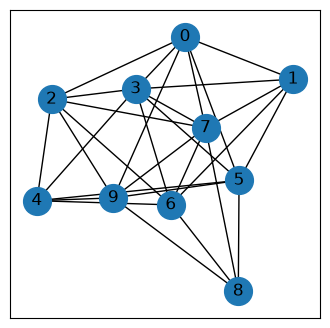

mesh 0: degree of contacts = 6
mesh 1: degree of contacts = 5
mesh 2: degree of contacts = 6
mesh 3: degree of contacts = 7
mesh 4: degree of contacts = 5
mesh 5: degree of contacts = 6
mesh 6: degree of contacts = 6
mesh 7: degree of contacts = 7
mesh 8: degree of contacts = 4
mesh 9: degree of contacts = 6

average degree of contacts: 5.80
standard deviation: 0.87



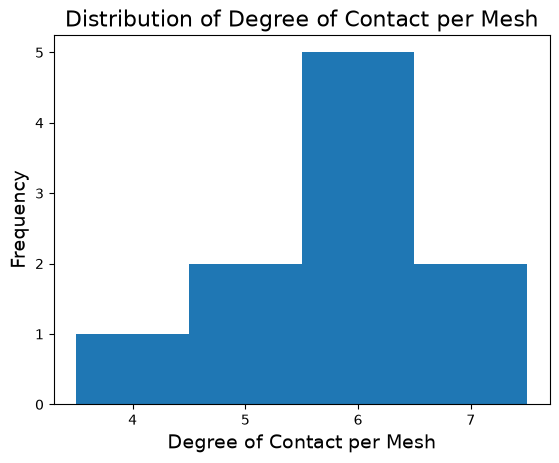

In [3]:
for job in project:
    if job.isfile('trajectory.gsd') and job.id == "89433309306eb7d9b0dee764e4d8d6d8":
        traj = gsd.hoomd.open(job.fn("trajectory.gsd")) 
        break

frame = traj[-1]
box = freud.box.Box.from_box(frame.configuration.box)
# print(frame.log.keys())
print(job.sp)

G = contact_network(frame, job.sp.N_part, job.sp.N_mesh, distance = job.sp.sigma)
plt.figure(figsize=(4,4))
nx.draw_networkx(G, node_size = 400)
plt.savefig("graph.png", bbox_inches='tight')
plt.show() 
print(contact_degrees(frame, job.sp.N_part, job.sp.N_mesh, distance = job.sp.sigma))


# forces = frame.log["particles/md/pair/Table/forces"]
# print(mesh_force(forces[:, 0:2], job.sp.N_part, job.sp.N_mesh))

# print(contact_degrees(frame, job.sp.N_part, job.sp.N_mesh, distance = job.sp.sigma))

In [20]:
for job in project:
    if job.isfile('trajectory.gsd') and job.doc.get("reference_trial_number") == 13: 
        traj = gsd.hoomd.open(job.fn("trajectory.gsd")) 
        break

frame = traj[-1]
box = freud.box.Box.from_box(frame.configuration.box)
# print(frame.log.keys())
print(job.sp)

print(forces_between_mesh(frame, job.sp.N_part, job.sp.N_mesh, job.sp.sigma, job.sp.k_harm, box))


{'N_part': 5, 'N_mesh': 256, 'sigma': 2.09, 'sigma_scale': 1.6, 'R': 4, 'phi_init': 0.1, 'phi_fin': 1.0, 'k_bend': 1.0, 'k_area_scale': 100, 'k_volume_scale': 100000, 'k_harm': 100, 'Lz_fin': 4, 'replica_index': 0}
{'avg_particle_num': 91.4, 'avg_pair_force': 436.46349334716797, 'avg_particle_force': 4.782345685565073, 'contact_fraction': 0.35703125, 'pair_force': {(0, 1): 555.2660522460938, (0, 2): 468.4793395996094, (0, 3): 472.2529296875, (0, 4): 226.3525848388672, (1, 2): 475.00958251953125, (1, 3): 471.6602783203125, (1, 4): 224.7347412109375, (2, 3): 830.9998168945312, (2, 4): 321.3551940917969, (3, 4): 318.5244140625}, 'pair_contacts': {(0, 1): 120, (0, 2): 86, (0, 3): 91, (0, 4): 54, (1, 2): 92, (1, 3): 89, (1, 4): 51, (2, 3): 191, (2, 4): 72, (3, 4): 68}}


mesh 0: degree of contacts = 4
mesh 1: degree of contacts = 4
mesh 2: degree of contacts = 4
mesh 3: degree of contacts = 4
mesh 4: degree of contacts = 4

average degree of contacts: 4.00
standard deviation: 0.00



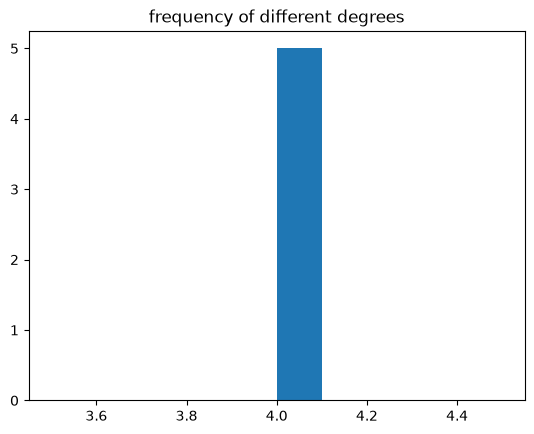

In [9]:
for job in project:
    if job.isfile('trajectory.gsd') and job.doc.get("reference_trial_number") == 26: 
        traj = gsd.hoomd.open(job.fn("trajectory.gsd")) 
        break
frame = traj[-1]
box = freud.box.Box.from_box(frame.configuration.box)

print(contact_degrees(frame, job.sp.N_part, job.sp.N_mesh, distance = job.sp.sigma))
